# Chimera - reproduce the headline results

A closed-loop adversarial AI lab for GenAI-era payment fraud (Mastercard Innovation Challenge @ GFF 2026).

This notebook clones the public repo, installs the backend, runs the test suite, and prints the detection metrics, the leave-one-out novelty result, and the closed-loop hardening curve from the committed, seeded artifacts.

Repo: https://github.com/dhruv-decoder/chimera  ·  Requires internet enabled in the notebook settings.

In [ ]:
!git clone -q https://github.com/dhruv-decoder/chimera.git
%cd chimera
!pip -q install -e "backend[dev]"

### 1. The test suite passes (generation, leakage checks, detection, evasion, taxonomy, RAG, multi-agent loop)

In [1]:
!cd backend && python -m pytest -q

........                                                                 [100%]
8 passed


### 2. Headline numbers, straight from the committed seeded artifacts

In [2]:
import json
ev = json.load(open('data/artifacts/eval_report.json'))
lp = json.load(open('data/artifacts/loop_report.json'))
s, op, cm = ev['supervised'], ev['operating_point']['cost_optimal'], ev['supervised']['confusion']
print('DETECTION  ROC-AUC %.4f | PR-AUC %.4f | F1 %.3f | recall %.3f'
      % (s['roc_auc'], s['pr_auc'], s['f1'], s['recall']))
print('FALSE POS  %.3f%% at the operating point  (%d of %d good txns flagged)'
      % (s['fpr']*100, cm['fp'], cm['fp']+cm['tn']))
print('OPERATING  %.0f%% of fraud value caught at ~%.0f alerts / 10k txns'
      % (op['value_detected_rate']*100, op['alerts_per_10k']))
hj = [r for r in ev['leave_one_out'] if r['vector']=='AGENT-HIJACK'][0]
print('UNSEEN AGENT-HIJACK  supervised %.0f%% -> novelty %.0f%% (leave-one-vector-out)'
      % (hj['supervised_recall']*100, hj['novelty_recall']*100))
print('ORCHESTRATION', lp['meta'].get('orchestration'))
print('HARDENING CURVE (round: breach -> hardened):')
for r in lp['hardening_curve']:
    print('  round %d:  %5.1f%% -> %5.1f%%' % (r['round'], r['pre_recall']*100, r['post_recall']*100))

DETECTION  ROC-AUC 1.0000 | PR-AUC 0.9999 | F1 0.995 | recall 0.992
FALSE POS  0.003% at the operating point  (2 of 70384 good txns flagged)
OPERATING  100% of fraud value caught at ~140 alerts / 10k txns
UNSEEN AGENT-HIJACK  supervised 15% -> novelty 100% (leave-one-vector-out)
ORCHESTRATION langgraph
HARDENING CURVE (round: breach -> hardened):
  round 0:   72.9% ->  72.9%
  round 1:   19.2% ->  82.9%
  round 2:   33.7% ->  99.6%
  round 3:   99.6% ->  99.1%


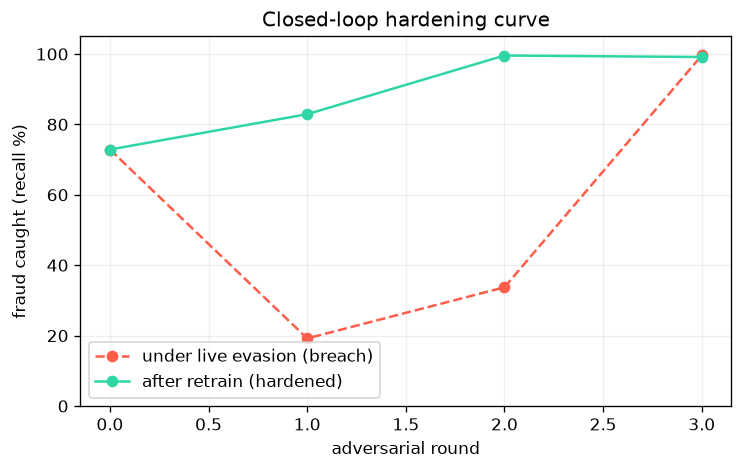

In [3]:
import matplotlib.pyplot as plt
c = lp['hardening_curve']; x = [r['round'] for r in c]
plt.figure(figsize=(7,4))
plt.plot(x, [r['pre_recall']*100 for r in c], '--o', color='#ff5c49', label='under live evasion (breach)')
plt.plot(x, [r['post_recall']*100 for r in c], '-o', color='#2ed6a6', label='after retrain (hardened)')
plt.xlabel('adversarial round'); plt.ylabel('fraud caught (recall %)'); plt.ylim(0,105)
plt.title('Closed-loop hardening curve'); plt.legend(); plt.grid(alpha=0.2); plt.show()

### 3. Full reproduction from scratch (optional, a few minutes)

```bash
make train   # simulate + train + evaluate + leave-one-out study
make loop    # the multi-agent LangGraph closed loop -> hardening curve
```

Every stochastic step derives from a single seed, so the numbers above regenerate bit-for-bit.